In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
class Value:
    # constructor
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 # initially assuming this var doesn't affect loss fxn(L)
        self._backward = lambda: None  
        self._prev = set(_children) #children of curr Value
        self._op = _op #what operation created the value
        #converting tuple to a set
        #and storing it in a variable called _prev of type set
        #maintaining what values produce what other values
        self.label = label

    # string representation while printing
    def __repr__(self):
        return f"Value(data = {self.data}, label = \'{self.label}\')"

    # special methods or dunder methods ("double underscore")
    def __add__(self, other):
        # isinstance(obj, Class) checks whether an object belongs to a class.
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            # using chain rule
            self.grad += 1.0 * out.grad #local deriv * out's grad
            other.grad += 1.0 * out.grad
        out._backward = _backward # storing the function
        
        return out

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad #local deriv * out's grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out

    def __rmul__(self, other):
        # right multiplication
        # when we do a*b -> if a.__mul__(b) doesn't work, python calles b.__rmul__(a)
        return self * other

    def __pow__(self, other):
        # assert condition, "error message"
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(data=self.data**other, _children=(self, ), _op=f'**{other}'  )

        def _backward():
            self.grad += (other * (self.data**(other-1)) * out.grad)
        out._backward = _backward

        return out
        
    def __truediv__(self, other):
        return self * other**-1 # a * (b**-1) = a/b
        
    def tanh(self):
        x = self.data
        tan = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(tan, (self,) , 'tanh')

        def _backward():
            self.grad += (1-tan**2) * out.grad
        out._backward = _backward
        return out
        
    def exp(self):
        x = self.data
        out = Value(data=math.exp(x), _children = (self,), _op='exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out  
        
    def backward(self):
        # calling gradient in backward direction, starting from output towards input, using chain rule of deriv
        #Using topological sort
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [3]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir':'LR'}) #LR to left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a reactangular ('record') node for it
        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            # if this value is a result of some operation, create an op-node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [4]:
# inputs x1,x2 - axon
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2 (synaptic strengths)
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 + b`
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

# activation function - tanh - squashing input
o = n.tanh();
o.label = 'o'
o.backward()

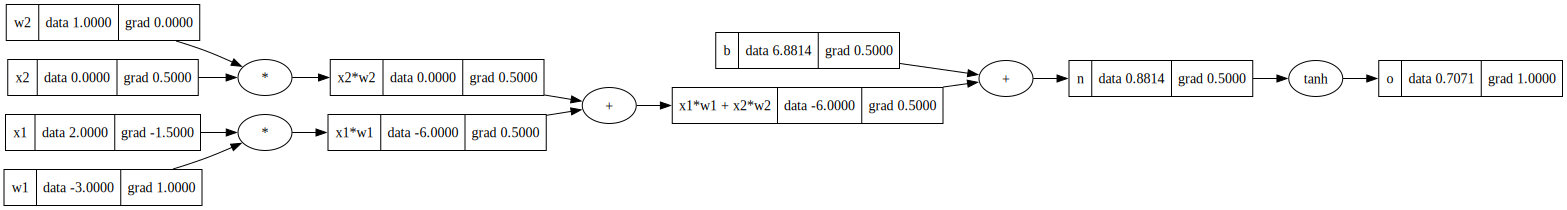

In [5]:
draw_dot(o)

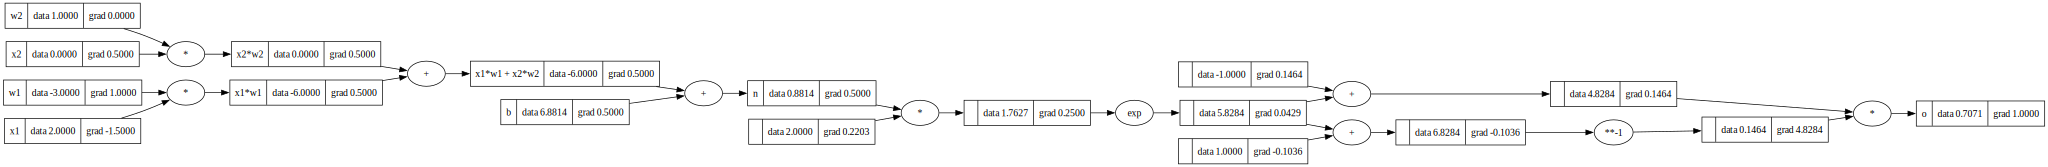

In [6]:
# inputs x1,x2 - axon
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2 (synaptic strengths)
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 + b`
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

#------
# activation function - tanh - squashing input
# expanding tanh into its exp definition
e = (2*n).exp()
o = (e-1)/(e+1)

#------
o.label = 'o'
o.backward()

draw_dot(o)

In [7]:
import torch

In [8]:
x1 = torch.Tensor([2.0]).double()                  ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                  ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()                 ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                  ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()    ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('----')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
----
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [29]:
import random

class Neuron:
    def __init__(self, nin):
        # List comprehension:[new_value for item in iterable]
        # nin -> no of input -> no of inputs a neuron gets 
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        #returns object(x) # makes the neuron callable like a function: n(x)

        #n(x) neuron n gets array,list x as input
        
        # zip - It combines multiple iterables element by element in a tuple
        # using generator exp
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        # sum(iterable, start(def = 0))
        out = act.tanh()         
        return out  

    def parameters(self):
        return self.w + [self.b]

class Layer:
    
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
        # create nout neurons
        # each neuron accepts nin inputs

    def __call__(self, x):
        # passing actual inputs in list x to each neuron structure formed
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

    # model = MLP(3, [4,4,1] (describe each layer))
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        # feeding values into each layer sequentially
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [165]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)

Value(data = -0.8886738953343647, label = '')

In [166]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [208]:
# mean squared error - Loss
# ygt is y-ground-truth

# do zero_grad() before backwards

for k in range(20):
    
    # Forward pass
    ypred = [n(x) for x in xs]
    loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0.0))

    # Backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    # basically means "Compute the gradient of loss with respect
    # to every Value object that contributed to creating this loss."

    # Update
    for p in n.parameters():
        p.data += -0.1 * p.grad # as we need to decrease loss 

    print(k, loss.data)

0 0.0007246330063688125
1 0.0007226894111837213
2 0.0007207560254718291
3 0.0007188327696696958
4 0.00071691956503427
5 0.0007150163336324157
6 0.000713122998330523
7 0.0007112394827843326
8 0.0007093657114288939
9 0.0007075016094686907
10 0.0007056471028678844
11 0.0007038021183407699
12 0.0007019665833422895
13 0.0007001404260587379
14 0.0006983235753986174
15 0.000696515960983614
16 0.0006947175131396988
17 0.0006929281628883576
18 0.0006911478419379987
19 0.0006893764826753964


In [209]:
ypred

[Value(data = 0.9861645120205174, label = ''),
 Value(data = -0.9912722599857882, label = ''),
 Value(data = -0.985541320933319, label = ''),
 Value(data = 0.9854147708644658, label = '')]